# 2/ Definitions

In [29]:
# helper code needed for running in colab
if 'google.colab' in str(get_ipython()):
    print('Downloading plot_helpers.py to util/ (only neded for colab')
    !mkdir util; wget https://raw.githubusercontent.com/minireference/noBSLAnotebooks/master/util/plot_helpers.py -P util

mkdir: cannot create directory ‘util’: File exists
--2026-09-11 06:44:33--  https://raw.githubusercontent.com/minireference/noBSLAnotebooks/master/util/plot_helpers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9555 (9.3K) [text/plain]
Saving to: ‘util/plot_helpers.py.1’

plot_helpers.py.1   100%[===================>]   9.33K  --.-KB/s    in 0s      

2026-09-11 06:44:33 (25.9 MB/s) - ‘util/plot_helpers.py.1’ saved [9555/9555]



In [30]:
# setup SymPy
from sympy import *
x, y, z, t = symbols('x y z t')
init_printing()

# setup plotting
%matplotlib inline
import matplotlib.pyplot as mpl
from util.plot_helpers import plot_vec, plot_vecs, autoscale_arrows

## SymPy Matrix objects

In [31]:
v = Matrix([1,2,3])
v
# s = Matrix([[1, 2], [3, 4]])
# s
# 这个可以认为是x轴是1 y轴是2 z轴是3

⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣3⎦

In [32]:
# define symbolically
v_1, v_2, v_3 = symbols('v_1 v_2 v_3')
v = Matrix([v_1,v_2,v_3])

In [33]:
v

⎡v₁⎤
⎢  ⎥
⎢v₂⎥
⎢  ⎥
⎣v₃⎦

In [34]:
v.T
# 可以用excel 竖着排本来是第一列第一行 是v1 第一列第二行是v2 第一列第三行是v3
# v.T后   第一行第一列v1 第一行第二列v2 第一行第三列v3 参考下面的代码

[v₁  v₂  v₃]

In [38]:
from sympy import Matrix

# 1. 定义一个具体的列向量 v
v = Matrix([1, 2, 3])

# 2. 它的转置 v.T（行向量）
v_transpose = v.T

print("原本的列向量 v (竖着排，像 Excel 的第 A 列):")
display(v)

print("转置后的行向量 v.T (横着排，像 Excel 的第 1 行):")
display(v_transpose)

原本的列向量 v (竖着排，像 Excel 的第 A 列):


⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣3⎦

转置后的行向量 v.T (横着排，像 Excel 的第 1 行):


[1  2  3]

In [39]:
A = Matrix(
    [   [1,7],
        [2,8],
        [3,9]   ])
A

⎡1  7⎤
⎢    ⎥
⎢2  8⎥
⎢    ⎥
⎣3  9⎦

In [40]:
# define symbolically
a_11, a_12, a_21, a_22, a_31, a_32 = symbols('a_11 a_12 a_21 a_22 a_31 a_32')
A = Matrix([
        [a_11, a_12],
        [a_21, a_22],
        [a_31, a_32]])

In [11]:
A

⎡a₁₁  a₁₂⎤
⎢        ⎥
⎢a₂₁  a₂₂⎥
⎢        ⎥
⎣a₃₁  a₃₂⎦

## Vector operations

In [42]:
u_1, u_2, u_3 = symbols('u_1 u_2 u_3')
u = Matrix([u_1,u_2,u_3])
v_1, v_2, v_3 = symbols('v_1 v_2 v_3')
v = Matrix([v_1,v_2,v_3])
alpha = symbols('alpha')

u

⎡u₁⎤
⎢  ⎥
⎢u₂⎥
⎢  ⎥
⎣u₃⎦

In [43]:
alpha*u

⎡α⋅u₁⎤
⎢    ⎥
⎢α⋅u₂⎥
⎢    ⎥
⎣α⋅u₃⎦

In [44]:
u+v

⎡u₁ + v₁⎤
⎢       ⎥
⎢u₂ + v₂⎥
⎢       ⎥
⎣u₃ + v₃⎦

In [45]:
u.norm()


   _______________________
  ╱     2       2       2 
╲╱  │u₁│  + │u₂│  + │u₃│  

完全正确！一针见血！norm()（模长）的本质就是求距离。
更精确地说，它算的是：从原点 $(0, 0, 0)$ 出发，
一直到这个向量的终点（比如 $(u_1, u_2, u_3)$）所拉出来的那条“直线距离”。

为什么要这么做？（直观理解）
方向不变：因为你是把每个分量按比例缩小，所以向量的方向不会改变。

长度为 1：新向量
u
^
u
^
  的长度正好是 1。

应用场景：在物理和机器学习中，我们经常只关心方向（比如光照方向、法线方向），而不关心它有多长，这时候就需要把向量单位化。

In [46]:
uhat = u/u.norm()
uhat

⎡            u₁            ⎤
⎢──────────────────────────⎥
⎢   _______________________⎥
⎢  ╱     2       2       2 ⎥
⎢╲╱  │u₁│  + │u₂│  + │u₃│  ⎥
⎢                          ⎥
⎢            u₂            ⎥
⎢──────────────────────────⎥
⎢   _______________________⎥
⎢  ╱     2       2       2 ⎥
⎢╲╱  │u₁│  + │u₂│  + │u₃│  ⎥
⎢                          ⎥
⎢            u₃            ⎥
⎢──────────────────────────⎥
⎢   _______________________⎥
⎢  ╱     2       2       2 ⎥
⎣╲╱  │u₁│  + │u₂│  + │u₃│  ⎦

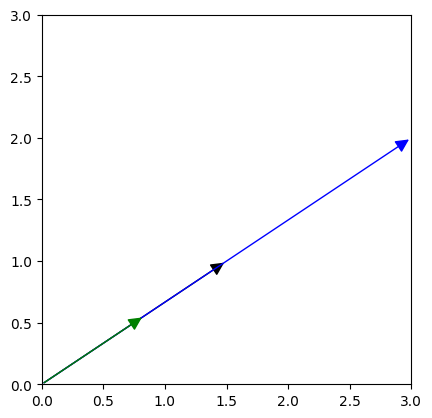

In [47]:
u = Matrix([1.5,1])
w = 2*u
uhat = u/u.norm()

plot_vecs(u, w, uhat)
autoscale_arrows()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas

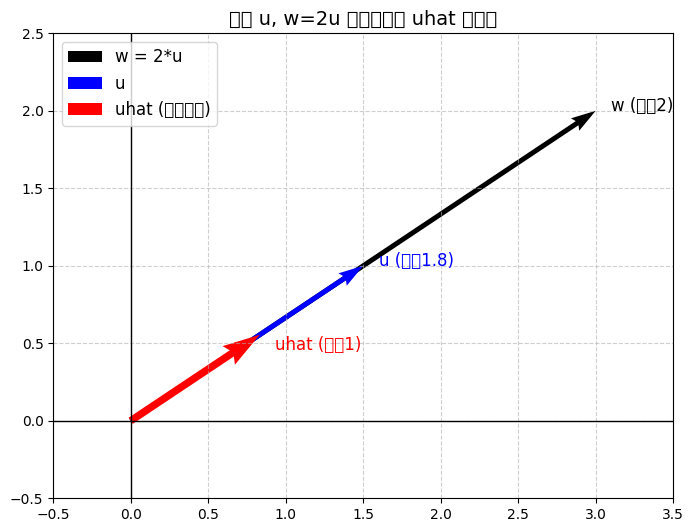

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义向量数据 (使用 numpy 便于计算)
u = np.array([1.5, 1])
w = 2 * u
uhat = u / np.linalg.norm(u)  # 单位向量，长度必定为 1

# 2. 设置画布
plt.figure(figsize=(8, 8))
ax = plt.gca()

# 3. 绘制向量 (使用不同颜色和线宽)
# 绘制 w (黑色，最长)
ax.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='black', width=0.008, label='w = 2*u')
# 绘制 u (蓝色，中等)
ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008, label='u')
# 绘制 uhat (红色，最短，稍微错开一点或者加粗以便看清)
ax.quiver(0, 0, uhat[0], uhat[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.012, label='uhat (单位向量)')

# 4. 添加文字标注 (直接标在箭头尖端附近)
ax.text(w[0]+0.1, w[1], 'w (长度2)', fontsize=12, color='black')
ax.text(u[0]+0.1, u[1], 'u (长度1.8)', fontsize=12, color='blue')
ax.text(uhat[0]+0.1, uhat[1]-0.1, 'uhat (长度1)', fontsize=12, color='red')

# 5. 设置坐标轴和网格
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal') # 保证 x 和 y 轴比例一致，这样长度看起来才准确
ax.grid(True, linestyle='--', alpha=0.6)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)

# 6. 添加图例
ax.legend(loc='upper left', fontsize=12)

plt.title("向量 u, w=2u 与单位向量 uhat 的对比", fontsize=14)
plt.show()

### Dot product

In [49]:
u = Matrix([u_1,u_2,u_3])
v = Matrix([v_1,v_2,v_3])

u.dot(v)

u₁⋅v₁ + u₂⋅v₂ + u₃⋅v₃

3

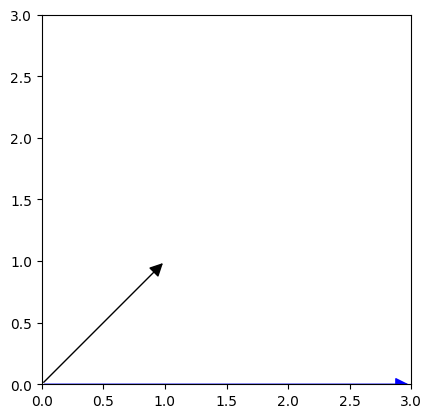

In [50]:
u = Matrix([1,1])
v = Matrix([3,0])
plot_vecs(u,v)
autoscale_arrows()

u_dot_v = u.dot(v)
u_dot_v

In [20]:
phi = acos( u.dot(v)/(u.norm()*v.norm()) )
print(u.dot(v))
print(u.norm())
print(v.norm())
print(u.norm() * v.norm())
print('angle between u and v is', phi)
u.norm()*v.norm()*cos(phi)

3
sqrt(2)
3
3*sqrt(2)
angle between u and v is pi/4


3

### Cross product

In [51]:
u = Matrix([u_1,u_2,u_3])
v = Matrix([v_1,v_2,v_3])

u.cross(v)

⎡u₂⋅v₃ - u₃⋅v₂ ⎤
⎢              ⎥
⎢-u₁⋅v₃ + u₃⋅v₁⎥
⎢              ⎥
⎣u₁⋅v₂ - u₂⋅v₁ ⎦

Matrix([[0], [0], [1]])


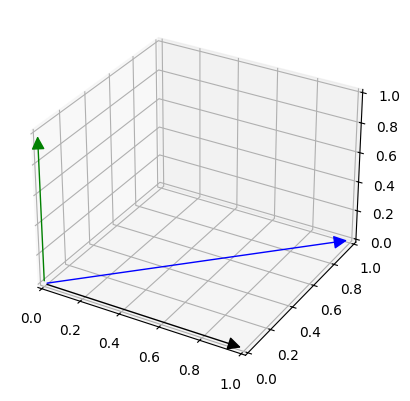

In [52]:
u = Matrix([1,0,0])
v = Matrix([1,1,0])
w = u.cross(v)      # a vector perpendicular to both u and v
print(w)
plot_vecs(u, v, u.cross(v))

## 1. 基础数据准备（预计算）在这部分，代码提前计算了后续公式频繁用到的基础物理量，避免了重复计算。len_u = u.norm() / len_v = v.norm()：计算向量 $u$ 和向量 $v$ 的模长（即长度），分别记作 $\vert{}u\vert{}$ 和 $\vert{}v\vert{}$。dot_uv = u.dot(v)：计算向量 $u$ 和 $v$ 的点积（内积）。几何意义上，点积公式为：$u \cdot v = \vert{}u\vert{} \vert{}v\vert{} \cos(\phi)$。norm_product = len_u * len_v：将两个向量的长度相乘，得到结果 $\vert{}u\vert{} \vert{}v\vert{}$。输出：打印出各个基础变量的值，并用横线分隔。## 2. 计算余弦值与夹角 $\phi$这部分利用点积的结果反推两个向量之间的夹角。cos_phi = dot_uv / norm_product：根据点积的几何定义变形：$\cos(\phi) = \frac{u \cdot v}{\vert{}u\vert{} \vert{}v\vert{}}$。这里用刚刚算好的点积除以长度乘积，求出夹角的余弦值。phi = acos(cos_phi)：通过反余弦函数（acos）将余弦值转化为对应的弧度角 $\phi$。输出：打印出夹角 $\phi$ 的弧度制大小。## 3. 验证叉积的模长公式这部分是代码的核心目的：验证向量叉积的模长几何公式是否成立。cross_len = w.norm()：这里的 $w$ 应该是由 $u \times v$ 得到的叉积向量。这里直接计算出叉积向量的实际模长 $\vert{}u \times v\vert{}$。expected_len = norm_product * sin(phi)：根据叉积的模长几何公式：$\vert{}u \times v\vert{} = \vert{}u\vert{} \vert{}v\vert{} \sin(\phi)$，计算出理论上的期望模长。cross_len == expected_len：对比实际计算出的叉积长度与公式推导出的长度是否相等。

点积（Dot Product，也叫内积或数量积）是线性代数中最核心的运算之一。简单来说，**点积的结果是一个数字（标量），它衡量了两个向量在“方向上的契合程度”**。

我们可以从**几何意义**、**代数意义**以及**实际应用**三个维度来彻底理解它：

---

### ## 1. 几何意义：投影与方向一致性

从几何上看，点积的公式是：


$$u \cdot v = \vert{}u\vert{} \vert{}v\vert{} \cos(\phi)$$


（其中 $\phi$ 是两个向量的夹角）

这个公式拆开来看，其实包含两个动作：

* **投影**：$\vert{}u\vert{} \cos(\phi)$ 表示向量 $u$ 在向量 $v$ 方向上的**投影长度**。
* **相乘**：再乘以 $v$ 的长度 $\vert{}v\vert{}$。

**直观理解**：点积反映了“一个向量有多大程度顺着另一个向量的方向走”。

* 如果两个向量方向完全一致（夹角为 $0^\circ$），它们的点积最大（全是正数相乘）。
* 如果两个向量毫无关系（垂直，夹角 $90^\circ$），它们的点积为 **$0$**（因为 $\cos(90^\circ) = 0$）。
* 如果两个向量方向相反（夹角大于 $90^\circ$），它们的点积为负数。

---

### ## 2. 代数意义：对应分量的乘积之和

在坐标系中，如果我们知道两个向量的具体坐标（例如三维向量 $u = (x_1, y_1, z_1)$ 和 $v = (x_2, y_2, z_2)$），点积的计算非常简单：


$$u \cdot v = x_1x_2 + y_1y_2 + z_1z_2$$

**直观理解**：把它们在各个轴（x轴、y轴、z轴）上的分量分别相乘，然后把结果加起来。它代表了**两个向量在各个维度上的“协同变化”程度**。

---

### ## 3. 点积在实际中有啥用？

在编程、游戏开发、图形学和机器学习中，点积最常用于以下场景：

* **判断垂直（正交）**：如果 `u.dot(v) == 0`，说明这两个向量垂直。这在判断墙面、法线、碰撞时极为常用。
* **计算夹角**：正如你刚才的代码一样，通过点积可以轻松反算出两个向量之间的夹角（$\cos(\phi) = \frac{u \cdot v}{\vert{}u\vert{}\vert{}v\vert{}}$）。
* **判断前后/视野**：在 3D 游戏里，用玩家的朝向向量和敌人相对于玩家的方位向量做点积，如果结果大于 0，说明敌人在玩家**正前方**；小于 0 则在**身后**。
* **光照计算**：计算光线方向向量和物体表面法线向量的点积，就能知道光照有多强（正面照射最亮，斜射变暗，背光为 0）。

---

通过刚才的代码，你觉得点积和叉积在直观感受上最大的区别是什么？

用一个具体的 **2D 坐标系例子**来理解“投影”会非常直观。

想象你在地上放了一根棍子（代表向量 $v$），头顶上有一个太阳垂直往下照，这根棍子在地上会有一个影子。如果你把另一根棍子（代表向量 $u$）斜着靠在第一根棍子上，它在第一根棍子（或它延伸的直线）上也会投下一个影子。这个影子的长度，就是**向量 $u$ 在向量 $v$ 方向上的投影长度**。

---

### ## 1. 设定一个具体的例子

假设我们在平面直角坐标系中：

* **向量 $v$** 沿着 x 轴正方向：$v = (4, 0)$。它的长度 $\vert{}v\vert{} = 4$。
* **向量 $u$** 往右上角斜着走：$u = (3, 3)$。
* 它的长度 $\vert{}u\vert{} = \sqrt{3^2 + 3^2} = \sqrt{18} \approx 4.24$。
* 因为 $u$ 在 x 和 y 方向的分量都是 3，所以它和 x 轴（向量 $v$）的夹角 $\phi = 45^\circ$。



---

### ## 2. 看看几何上的“投影”是什么

* 从向量 $u$ 的顶端 $(3, 3)$ 向向量 $v$ 所在的 x 轴垂直往下看（画一条垂线），它正好落在 x 轴的 **$3$** 这个位置。
* 这个从原点到 $3$ 的距离（也就是 **$3$**），就是 $u$ 在 $v$ 上的**投影长度**。

---

### ## 3. 用公式 $\vert{}u\vert{} \cos(\phi)$ 验证一下

我们把刚才的数据代入公式看看算出来对不对：

* $\vert{}u\vert{} = \sqrt{18}$
* $\phi = 45^\circ$，其余弦值 $\cos(45^\circ) = \frac{\sqrt{2}}{2}$

套用公式：


$$\text{投影长度} = \vert{}u\vert{} \cos(\phi) = \sqrt{18} \times \frac{\sqrt{2}}{2} = \frac{\sqrt{36}}{2} = \frac{6}{2} = 3$$

你看，公式算出来的结果 **$3$**，和我们从几何图形上看到的影子长度完全吻合！

---

### ## 4. 为什么点积要包含这个投影？

回到点积的公式：$u \cdot v = \vert{}u\vert{} \vert{}v\vert{} \cos(\phi)$。
它可以看作是：**($u$ 在 $v$ 上的投影长度) $\times$ ($v$ 的自身长度)**。
如果投影长度是负数（说明夹角大于 $90^\circ$，影子落在了 $v$ 的反方向），点积结果就是负数。

通过这个影子（投影）的例子，是不是对 $\vert{}u\vert{} \cos(\phi)$ 的物理/几何画面更清晰了？

向量 u: [4 0], 模长 |u| = 4.00
向量 v: [3 3], 模长 |v| = 4.24
点积 u·v = 12
夹角 phi = 45.00 度
v 在 u 上的投影向量 = [3. 0.]
投影长度 = 3.00


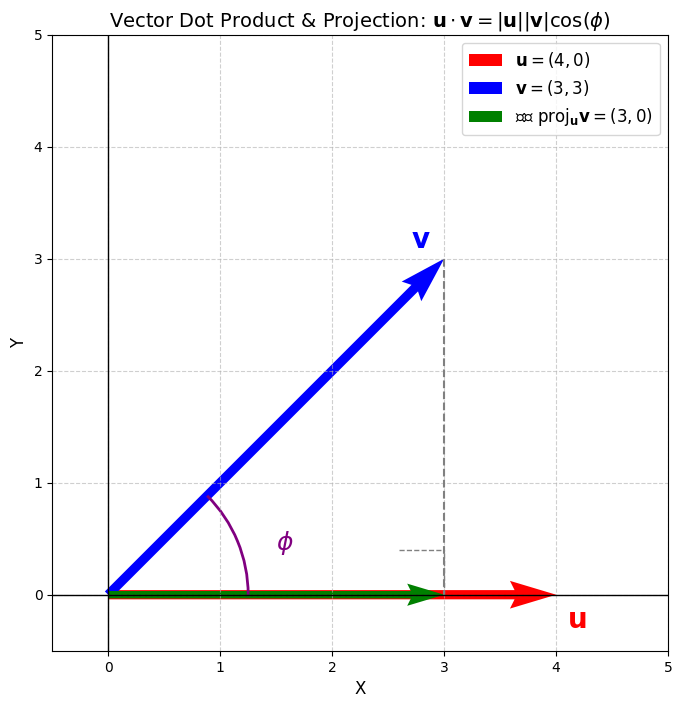

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义向量
u = np.array([4, 0])
v = np.array([3, 3])
origin = np.array([0, 0])

# 2. 计算核心数学量
dot_product = np.dot(u, v)
norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)
cos_phi = dot_product / (norm_u * norm_v)
phi_rad = np.arccos(cos_phi)
phi_deg = np.degrees(phi_rad)

# 计算 v 在 u 上的投影向量
# proj_u(v) = (u·v / |u|^2) * u
projection = (dot_product / np.dot(u, u)) * u

# 打印结果
print(f"向量 u: {u}, 模长 |u| = {norm_u:.2f}")
print(f"向量 v: {v}, 模长 |v| = {norm_v:.2f}")
print(f"点积 u·v = {dot_product}")
print(f"夹角 phi = {phi_deg:.2f} 度")
print(f"v 在 u 上的投影向量 = {projection}")
print(f"投影长度 = {np.linalg.norm(projection):.2f}")

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(8, 8))

# 绘制向量 u 和 v
ax.quiver(*origin, *u, color='red', angles='xy', scale_units='xy', scale=1, width=0.015, label=r'$\mathbf{u} = (4, 0)$')
ax.quiver(*origin, *v, color='blue', angles='xy', scale_units='xy', scale=1, width=0.015, label=r'$\mathbf{v} = (3, 3)$')

# 绘制投影向量 (绿色)
ax.quiver(*origin, *projection, color='green', angles='xy', scale_units='xy', scale=1, width=0.012, label=r'投影 $\text{proj}_{\mathbf{u}}\mathbf{v} = (3, 0)$')

# 绘制从 v 的末端到投影点的虚线 (表示垂直)
ax.plot([v[0], projection[0]], [v[1], projection[1]], color='gray', linestyle='--', linewidth=1.5)

# 绘制夹角弧线 phi
arc = plt.matplotlib.patches.Arc(origin, 2.5, 2.5, angle=0, theta1=0, theta2=phi_deg, color='purple', linewidth=2)
ax.add_patch(arc)

# 添加角度文字
ax.text(1.5, 0.4, r'$\phi$', fontsize=18, color='purple')
# 添加直角标记
ax.plot([3, 3], [0, 0.4], color='gray', linestyle='--', linewidth=1)
ax.plot([2.6, 3], [0.4, 0.4], color='gray', linestyle='--', linewidth=1)

# 添加向量标签文字
ax.text(u[0]+0.1, u[1]-0.3, r'$\mathbf{u}$', fontsize=20, color='red')
ax.text(v[0]-0.3, v[1]+0.1, r'$\mathbf{v}$', fontsize=20, color='blue')

# 4. 设置坐标轴样式
ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal') # 保证 x 和 y 轴比例一致
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.grid(True, linestyle='--', alpha=0.6)

# 添加图例和标题
ax.legend(loc='upper right', fontsize=12)
ax.set_title(r'Vector Dot Product & Projection: $\mathbf{u} \cdot \mathbf{v} = |\mathbf{u}||\mathbf{v}|\cos(\phi)$', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)

plt.show()

In [54]:
# 1. 先把基础数据算好并存起来，避免重复书写长代码
len_u = u.norm()
len_v = v.norm()
dot_uv = u.dot(v)
norm_product = len_u * len_v  # 两个向量长度的乘积 (|u| * |v|)

print("向量 u 的长度:", len_u)
print("向量 v 的长度:", len_v)
print("点积 (u·v):", dot_uv)
print("长度乘积 (|u|*|v|):", norm_product)
print("-" * 30)

# 2. 计算余弦值与夹角 phi
cos_phi = dot_uv / norm_product
phi = acos(cos_phi)
print("夹角 phi (弧度):", phi)
print("-" * 30)

# 3. 验证叉积的模长公式：|u × v| = |u| * |v| * sin(phi)
cross_len = w.norm()                  # 叉积 w 的实际长度
expected_len = norm_product * sin(phi)  # 公式理论计算出的长度

print("叉积 w 的实际长度:", cross_len)
print("公式计算出的长度 (|u||v|sin(phi)):", expected_len)
print("两边是否相等？", cross_len == expected_len)

向量 u 的长度: 1
向量 v 的长度: sqrt(2)
点积 (u·v): 1
长度乘积 (|u|*|v|): sqrt(2)
------------------------------
夹角 phi (弧度): pi/4
------------------------------
叉积 w 的实际长度: 1
公式计算出的长度 (|u||v|sin(phi)): 1
两边是否相等？ True


## Projection operation

In [ ]:
def proj(vec, d):
    """Computes the projection of vector `vec` onto vector `d`."""
    return d.dot(vec)/d.norm() * d/d.norm()

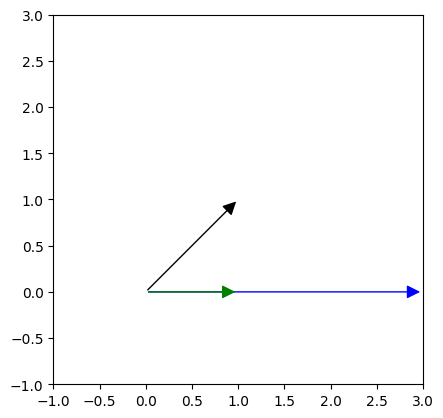

In [ ]:
u = Matrix([1,1])
v = Matrix([3,0])

pu_on_v = proj(u,v)

plot_vecs(u, v, pu_on_v)

ax = mpl.gca()
ax.set_xlim([-1,3])
ax.set_ylim([-1,3]);

# Matrix operations

In [ ]:
a_11, a_12, a_21, a_22, a_31, a_32 = symbols('a_11 a_12 a_21 a_22 a_31 a_32')
A = Matrix([
        [a_11, a_12],
        [a_21, a_22],
        [a_31, a_32]])
b_11, b_12, b_21, b_22, b_31, b_32 = symbols('b_11 b_12 b_21 b_22 b_31 b_32')
B = Matrix([
        [b_11, b_12],
        [b_21, b_22],
        [b_31, b_32]])
alpha = symbols('alpha')

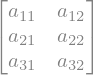

In [ ]:
A

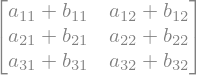

In [ ]:
A + B

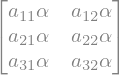

In [ ]:
alpha*A

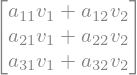

In [ ]:
v_1, v_2 = symbols('v_1 v_2')
v = Matrix([v_1,v_2])

A*v

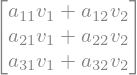

In [ ]:
A[:,0]*v[0] + A[:,1]*v[1]

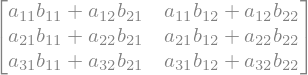

In [ ]:
A = Matrix([
        [a_11, a_12],
        [a_21, a_22],
        [a_31, a_32]])
B = Matrix([
        [b_11, b_12],
        [b_21, b_22]])

A*B

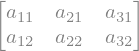

In [ ]:
A.T

In [ ]:
print('the shape of v is', v.shape)
v

the shape of v is (2, 1)


In [ ]:
print('the shape of v.T is', v.T.shape)
v.T

the shape of v.T is (1, 2)


In [ ]:
u = Matrix([u_1,u_2,u_3])
v = Matrix([v_1,v_2,v_3])

u.T*v

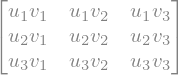

In [ ]:
u * v.T

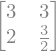

In [ ]:
A = Matrix([
        [3,       3],
        [2,  S(3)/2]
])
A

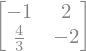

In [ ]:
A.inv()

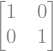

In [ ]:
A * A.inv()

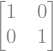

In [ ]:
A.inv() * A

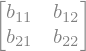

In [ ]:
B = Matrix([
        [b_11, b_12],
        [b_21, b_22]])
B

In [ ]:
B.trace()

In [ ]:
B.det()